#### Functions

In [42]:
# Example 1: A Simple Function with Dummy Data
def score_label(score):
    if score >= 90:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"
    
score_label(85)

'Good'

In [43]:
import pandas as pd

df_scores = pd.DataFrame({
    "student": ["Anna", "Ben", "Chris", "Diana", "Eva"],
    "score": [95, 78, 61, 43, 88]
})

df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [44]:
# Option 1 | apply
df_scores["score_label"] = df_scores["score"].apply(score_label)

df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [45]:
# Option 2 | with list comprehension
df_scores["score_label"] = [score_label(i) for i in df_scores["score"]]

df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [46]:
# Default Arguments in Functions
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"

classify_price(9)

'Mid-range product'

In [47]:
classify_price(9, low=3, high=10)

'Mid-range product'

In [48]:
# Example 2: Synthetic Data for Product Price Segments
df_product_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheede", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_product_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheede,12.0
4,Steak,24.5
5,Apples,4.2


In [49]:
df_product_dummy["price_range"] = df_product_dummy["price"].apply(classify_price)

df_product_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheede,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


In [50]:
# Task 1
def age_group_label(age):
    if age < 30:
        return "Young"
    elif age <= 59:
        return "Middle"
    else:
        return "Senior"
    
age_group_label(45)

'Middle'

In [51]:
# Task 2
def income_band(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income <= high:
        return "Middle income"
    else:
        return "High income"
    
income_band(75000)

'High income'

In [52]:
# Task 3
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [53]:
df_customers_dummy["age_group"] = df_customers_dummy["age"].apply(age_group_label)
df_customers_dummy

,customer,age,income,age_group
0,A,22,18000,Young
1,B,35,42000,Middle
2,C,47,72000,Middle
3,D,63,95000,Senior
4,E,29,25000,Young


In [54]:
df_customers_dummy["income_group"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,age_group,income_group
0,A,22,18000,Young,Low income
1,B,35,42000,Middle,Middle income
2,C,47,72000,Middle,High income
3,D,63,95000,Senior,High income
4,E,29,25000,Young,Low income


In [82]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [59]:
df_instacart = pd.read_csv("../data/processed/instacart.csv")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,aisle,First Name,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,soft drinks,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,packaged cheese,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,yogurt,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,paper goods,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,candy chocolate,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [94]:
df_instacart.rename(columns={"Surnam": "Surname"}, inplace=True)

In [103]:
df_instacart.to_csv("../data/processed/instacart.csv")

####  Creating a price_range Column

In [ ]:
def price_label(row):
    if row["prices"] <= 5:
        return "Low-range product"
    elif row["prices"] <= 15:
        return "Mid-range product"
    elif row["prices"] > 15:
        return "High-range product"
    else:
        return "Not enough data"

In [62]:
df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     793573
Low-range product     365155
High-range product     14796
Nor enough data           75
Name: count, dtype: int64

In [ ]:
# Alternative: Creating the Same Column with .loc
df_instacart["price_range_loc"] = ""

df_instacart.loc[df_instacart["prices"] > 15, "price_range_loc"] = "High-range product"
df_instacart.loc[
    (df_instacart["prices"] > 5) & (df_instacart["prices"] <= 15),
    "price_range_loc"
] = "Mid-range product"
df_instacart.loc[df_instacart["prices"] <= 5, "price_range_loc"] = "Low-range product"

df_instacart["price_range_loc"].value_counts(dropna=False)

price_range_loc
Mid-range product     793573
Low-range product     365155
High-range product     14796
                          75
Name: count, dtype: int64

#### Creating an age_group Column

In [ ]:
def age_group(age):
    if age < 30:
        return "Young"
    if age < 60:
        return "Middle"
    else:
        return "Senior"
    
df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    554659
Senior    398689
Young     220251
Name: count, dtype: int64

#### Creating an income_group Column with Default Arguments

In [ ]:
def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"
    
df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      825665
Middle income    338888
Low income         9046
Name: count, dtype: int64

#### Creating an order_time_band Column

In [70]:
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"
    
df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    567488
Morning      367655
Evening      215872
Night         22584
Name: count, dtype: int64

#### Lambda Functions

In [72]:
df_scores["pass_flag"] = df_scores["score"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df_scores

,student,score,score_label,pass_flag
0,Anna,95,Excellent,Pass
1,Ben,78,Good,Pass
2,Chris,61,Pass,Pass
3,Diana,43,Fail,Fail
4,Eva,88,Good,Pass


In [73]:
# Example with the instacart DataFrame
df_instacart["expensive_product"] = df_instacart["prices"].apply(
    lambda x: "Expensive" if x > 15 else "Not expensive"
)
df_instacart["expensive_product"].value_counts()

expensive_product
Not expensive    1158803
Expensive          14796
Name: count, dtype: int64

#### Visualization Based on Derived Columns

### Product Counts by price_range

In [86]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

price_range_counts

price_range
Nor enough data           75
High-range product     14796
Low-range product     365155
Mid-range product     793573
Name: count, dtype: int64

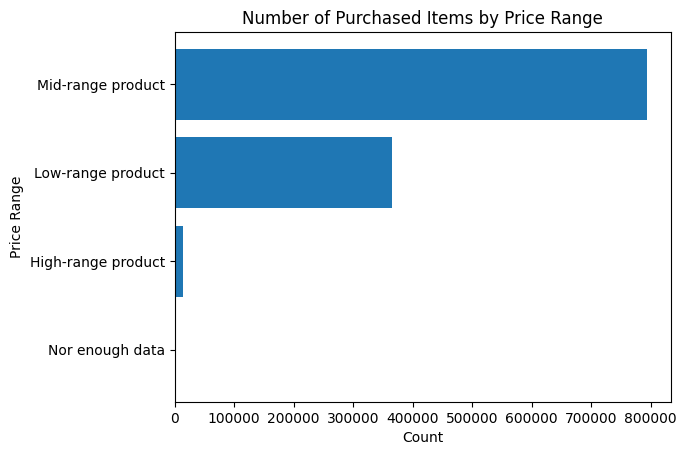

In [83]:
plt.figure()
plt.barh(price_range_counts.index, price_range_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel("Count")
plt.ylabel("Price Range")
plt.show()

#### Reorder Rate by price_range

In [88]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

reorder_by_price_range

price_range
High-range product    0.582725
Low-range product     0.591393
Mid-range product     0.602945
Nor enough data       0.653333
Name: reordered, dtype: float64

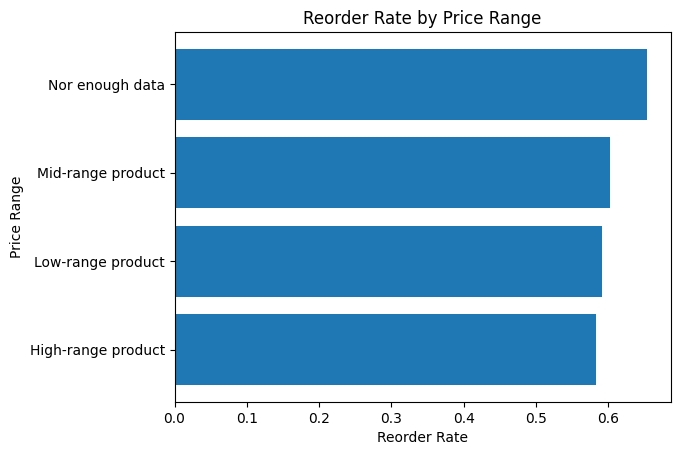

In [89]:
plt.figure()
plt.barh(reorder_by_price_range.index, reorder_by_price_range.values)
plt.title("Reorder Rate by Price Range")
plt.xlabel("Reorder Rate")
plt.ylabel("Price Range")
plt.show()

#### Customer Counts by age_group

In [95]:
df_customers_unique = df_instacart[
    ["First Name", "Surname", "Age", "income", "age_group", "income_group", "region"]
].drop_duplicates()

df_customers_unique.head()

,First Name,Surname,Age,income,age_group,income_group,region
0,Linda,Nguyen,31,40423,Middle,Middle income,South
11,Norma,Chapman,68,64940,Senior,Middle income,West
42,Janet,Lester,75,115242,Senior,High income,West
51,Peter,Villegas,39,89095,Middle,High income,Northeast
60,Anna,Allison,32,88603,Middle,High income,South


In [97]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()
age_group_counts

age_group
Young     20785
Senior    37952
Middle    52326
Name: count, dtype: int64

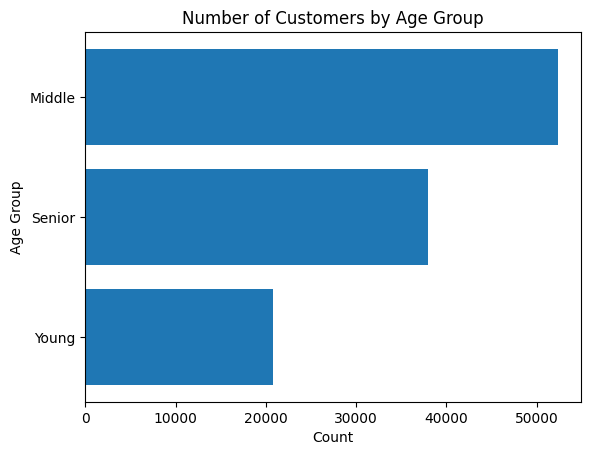

In [98]:
plt.figure()
plt.barh(age_group_counts.index, age_group_counts.values)
plt.title("Number of Customers by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

#### Average Income by age_group

In [99]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

avg_income_by_age_group

age_group
Young      67492.446283
Middle     94435.261075
Senior    109570.596385
Name: income, dtype: float64

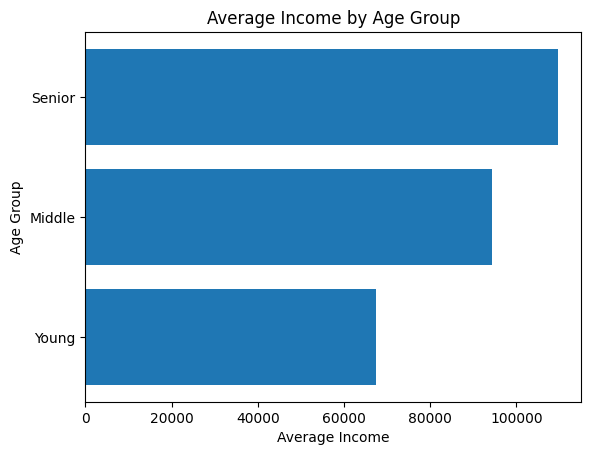

In [100]:
plt.figure()
plt.barh(avg_income_by_age_group.index, avg_income_by_age_group.values)
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.ylabel("Age Group")
plt.show()

#### Orders by order_time_band

In [101]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)
orders_time_band

order_time_band
Night         2108
Evening      20550
Morning      34707
Afternoon    53698
dtype: int64

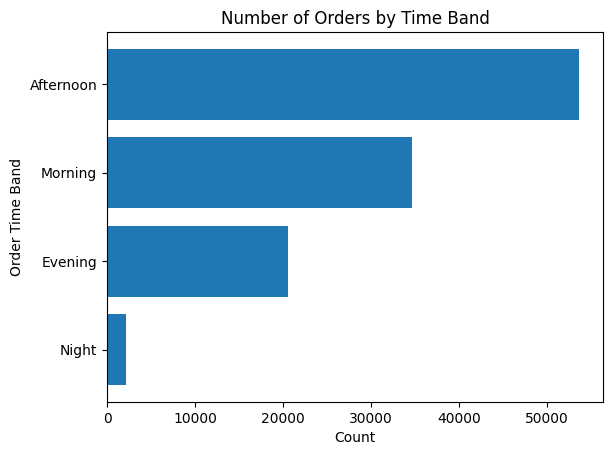

In [102]:
plt.figure()
plt.barh(orders_time_band.index, orders_time_band.values)
plt.title("Number of Orders by Time Band")
plt.xlabel("Count")
plt.ylabel("Order Time Band")
plt.show()

#### Practice Tasks

#### Task 1 | Create a derived column called family_size_group based on n_dependants.

In [106]:
df_instacart["n_dependants"].value_counts()

n_dependants
2    293952
3    293774
1    293247
0    292626
Name: count, dtype: int64

In [116]:
def family_type(n):
    if n == 0:
        return "No dependants"
    elif n <= 2:
        return "Small family"
    else:
        return "Large family"

df_instacart["family_size_group"] = df_instacart["n_dependants"].apply(family_type)
df_instacart["family_size_group"].value_counts(dropna=False)

family_size_group
Small family     587199
Large family     293774
No dependants    292626
Name: count, dtype: int64

#### Task 2 | Create a derived column called senior_flag based on Age.

In [121]:
def senior_flag(age):
    if age >= 60:
        return "Senior"
    else:
        return "No senior"
    
df_instacart["senior_flag"] = df_instacart["Age"].apply(senior_flag)
df_instacart["senior_flag"].value_counts(dropna=False)

senior_flag
No senior    774910
Senior       398689
Name: count, dtype: int64

#### Task 3 | Visualize the number of customers by income_group

In [129]:
income_counts = df_instacart["income_group"].value_counts().sort_values()

income_counts

income_group
Low income         9046
Middle income    338888
High income      825665
Name: count, dtype: int64

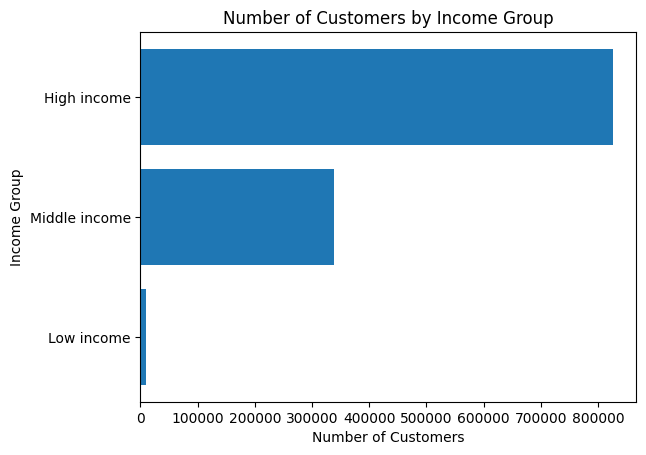

In [133]:
plt.figure()
plt.barh(income_counts.index, income_counts.values)
plt.title("Number of Customers by Income Group")
plt.xlabel("Number of Customers")
plt.ylabel("Income Group")
plt.show()

#### Task 4 | Visualize the reorder rate by order_time_band

In [138]:
reorder_by_time = df_instacart.groupby("order_time_band")["reordered"].mean()
reorder_by_time

order_time_band
Afternoon    0.588608
Evening      0.593491
Morning      0.619426
Night        0.585414
Name: reordered, dtype: float64

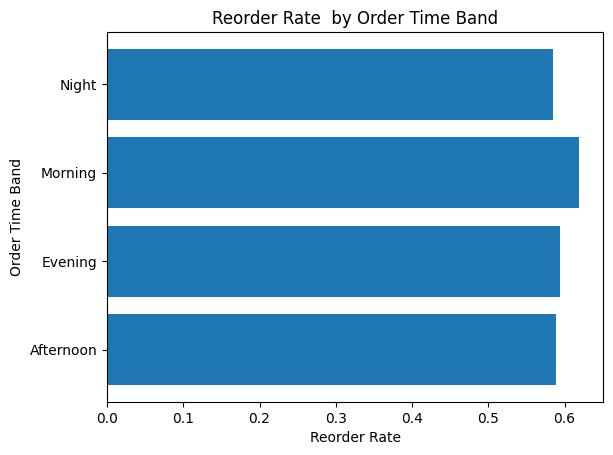

In [139]:
plt.figure()
plt.barh(reorder_by_time.index, reorder_by_time.values)
plt.title("Reorder Rate  by Order Time Band")
plt.xlabel("Reorder Rate")
plt.ylabel("Order Time Band")
plt.show()

#### Task 5 | Create a flag variable on dow using both lambda and isin() methods:

In [149]:
weekend_days = [6, 0]

# lambda()
df_instacart["is_weekend"] = df_instacart["order_dow"].apply(lambda x: True if x in weekend_days else False)
df_instacart["is_weekend"].value_counts()

is_weekend
False    721665
True     451934
Name: count, dtype: int64

In [150]:
# isin()
df_instacart["is_weekend_isin"] = df_instacart["order_dow"].isin(weekend_days)

In [154]:
# Check
df_instacart[["order_dow", "is_weekend", "is_weekend_isin"]].head(10)

,order_dow,is_weekend,is_weekend_isin
0,4,False,False
1,4,False,False
2,4,False,False
3,4,False,False
4,4,False,False
5,4,False,False
6,4,False,False
7,4,False,False
8,4,False,False
9,4,False,False
